# Entry-Level and Role Category Analysis

This notebook analyzes Saudi data-related job postings by role category and experience level.

The goal is to understand which roles, tools, and skills are most relevant for entry-level students and early-career learners interested in data-related careers in Saudi Arabia.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Cleaned Dataset

This section loads the cleaned Saudi data jobs dataset from GitHub.

In [3]:
url = "https://raw.githubusercontent.com/Reemaalsharif/Saudi-Data-Internship-Readiness-Map/main/data/saudi_data_jobs_cleaned.csv"

df = pd.read_csv(url)

df.head()

,job_id,job_title,company,city,role_type,experience_level,skills,tools,source,job_link,date_collected,notes,city_cleaned,experience_category,role_category
0,1,Data Analyst,ALESAYI HOLDING,Jeddah,Data Analyst,Entry level / 3 years,"customer data analysis, operational performanc...","Excel, PowerPoint, dashboards",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Customer experience data analyst role in autom...,Jeddah,Entry Level,Data Analysis
1,2,Geological Data Scientist,Maaden Barrick Copper Company,Mahd Adh Dhahab,Data Scientist,Entry level / 2-5 years,"geological data management, data quality manag...","SQL, Python, Power BI, Tableau, relational dat...",LinkedIn,https://sa.linkedin.com/jobs/view/geological-d...,2026-06-30,Mining sector data science role. Focuses on ge...,Mahd Adh Dhahab,Entry Level,Data Science
2,3,Data Analyst,PrimeGate for Communications and IT,Riyadh,Data Analyst,Entry level,"data analysis, insights generation, dashboardi...","SQL, Power BI, Tableau, Looker, Excel, Python,...",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Entry-level data analyst role for Madinaty Sup...,Riyadh,Entry Level,Data Analysis
3,4,Analyst Pricing Analytics and Insights,Schneider Electric,Saudi Arabia,Business / Pricing Analytics,Entry level,"pricing analytics, data analysis, data interpr...","data visualization, dashboards, charts, reports",LinkedIn,https://sa.linkedin.com/jobs/view/analyst-pric...,2026-06-30,Entry-level pricing analytics role. Focuses on...,Not specified,Entry Level,Data Analysis
4,5,Power BI Developer,Acuative Middle East,Jeddah,BI / Power BI Developer,Mid-level,"Power BI dashboard development, business intel...","Power BI Desktop, Power BI Service, DAX, Power...",LinkedIn,https://sa.linkedin.com/jobs/view/power-bi-dev...,2026-06-30,Mid-level Power BI Developer role in Jeddah. F...,Jeddah,Mid-Level,BI


## Dataset Overview

This section checks the dataset size and columns before starting the analysis.

In [5]:
df.shape

(25, 15)

In [6]:
df.columns

Index(['job_id', 'job_title', 'company', 'city', 'role_type',
       'experience_level', 'skills', 'tools', 'source', 'job_link',
       'date_collected', 'notes', 'city_cleaned', 'experience_category',
       'role_category'],
      dtype='object')

In [7]:
df[['job_title', 'city_cleaned', 'experience_category', 'role_category', 'skills', 'tools']].head()

,job_title,city_cleaned,experience_category,role_category,skills,tools
0,Data Analyst,Jeddah,Entry Level,Data Analysis,"customer data analysis, operational performanc...","Excel, PowerPoint, dashboards"
1,Geological Data Scientist,Mahd Adh Dhahab,Entry Level,Data Science,"geological data management, data quality manag...","SQL, Python, Power BI, Tableau, relational dat..."
2,Data Analyst,Riyadh,Entry Level,Data Analysis,"data analysis, insights generation, dashboardi...","SQL, Power BI, Tableau, Looker, Excel, Python,..."
3,Analyst Pricing Analytics and Insights,Not specified,Entry Level,Data Analysis,"pricing analytics, data analysis, data interpr...","data visualization, dashboards, charts, reports"
4,Power BI Developer,Jeddah,Mid-Level,BI,"Power BI dashboard development, business intel...","Power BI Desktop, Power BI Service, DAX, Power..."


## Role Category Distribution

This section analyzes how many job postings are available in each role category.

In [8]:
role_counts = df['role_category'].value_counts()

role_counts

,count
role_category,
Data Analysis,9
Other,5
AI,4
BI,3
Data Science,2
Governance,2


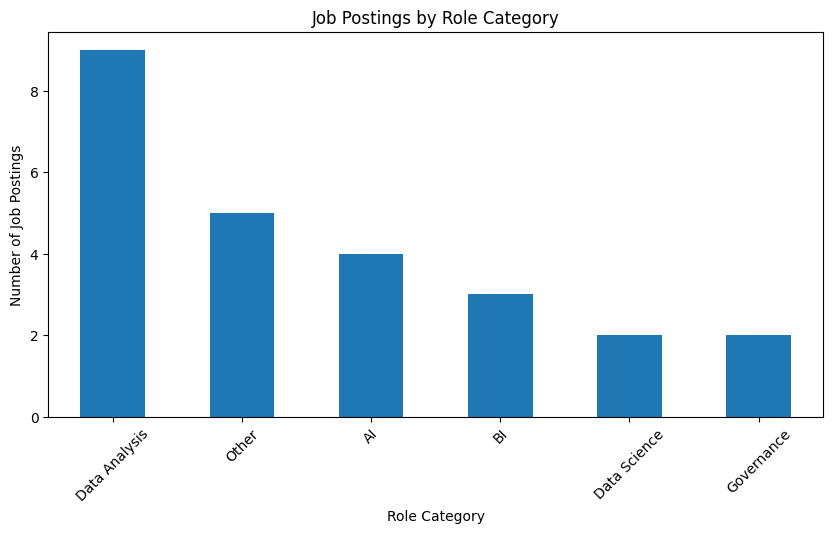

In [9]:
role_counts.plot(kind='bar', figsize=(10, 5))

plt.title('Job Postings by Role Category')
plt.xlabel('Role Category')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.show()

### Role Category Insight

The dataset includes multiple data-related role categories, such as Data Analysis, Data Science, BI, AI, Governance, Internship, and Other.

This shows that data-related opportunities in Saudi Arabia are not limited to only Data Analyst or Data Scientist job titles.

## Experience Level Distribution

This section analyzes the distribution of job postings by experience level.

In [10]:
experience_counts = df['experience_category'].value_counts()

experience_counts

,count
experience_category,
Entry Level,12
Mid-Level,11
Internship,2


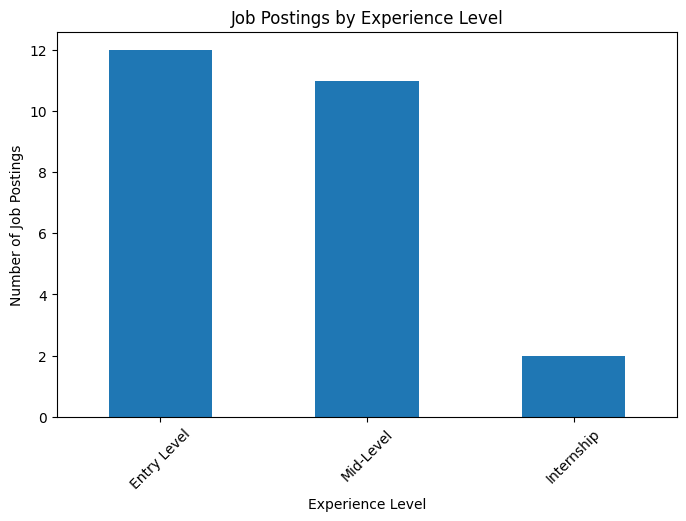

In [11]:
experience_counts.plot(kind='bar', figsize=(8, 5))

plt.title('Job Postings by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.show()

### Experience Level Insight

Most of the collected job postings are Entry Level or Mid-Level.

This supports the project goal of identifying skills and tools that are useful for students and early-career Computer Science learners.

## Entry-Level Job Postings

This section filters the dataset to focus only on entry-level opportunities.

In [12]:
entry_level_jobs = df[df['experience_category'] == 'Entry Level']

entry_level_jobs[['job_title', 'company', 'city_cleaned', 'role_category', 'experience_category']]

,job_title,company,city_cleaned,role_category,experience_category
0,Data Analyst,ALESAYI HOLDING,Jeddah,Data Analysis,Entry Level
1,Geological Data Scientist,Maaden Barrick Copper Company,Mahd Adh Dhahab,Data Science,Entry Level
2,Data Analyst,PrimeGate for Communications and IT,Riyadh,Data Analysis,Entry Level
3,Analyst Pricing Analytics and Insights,Schneider Electric,Not specified,Data Analysis,Entry Level
5,2026 KSA Analyst Program - Data and AI Analyst,Infinite PL,Riyadh,AI,Entry Level
6,Data Scientist I,MOZN,Not specified,Data Science,Entry Level
7,Specialist Operations Performance,DP World,Jeddah,Other,Entry Level
9,Junior Digital Marketing Analyst,Aqar,Riyadh,Other,Entry Level
15,MI and Data Analysis Analyst,FNRCO,Riyadh,Data Analysis,Entry Level
17,Business Intelligence Developer,Saudi Air Navigation Services,Not specified,BI,Entry Level


In [13]:
entry_level_jobs.shape

(12, 15)

## Entry-Level Tools Analysis

This section analyzes the most frequently mentioned tools in entry-level data-related job postings.

In [14]:
entry_tools_series = entry_level_jobs['tools'].str.split(',')
entry_tools_exploded = entry_tools_series.explode()
entry_tools_cleaned = entry_tools_exploded.str.strip()
entry_tool_counts = entry_tools_cleaned.value_counts()

entry_tool_counts.head(10)

,count
tools,
Excel,6
SQL,5
dashboards,4
Python,4
Tableau,4
Power BI,4
PowerPoint,3
data visualization,2
BI tools,2


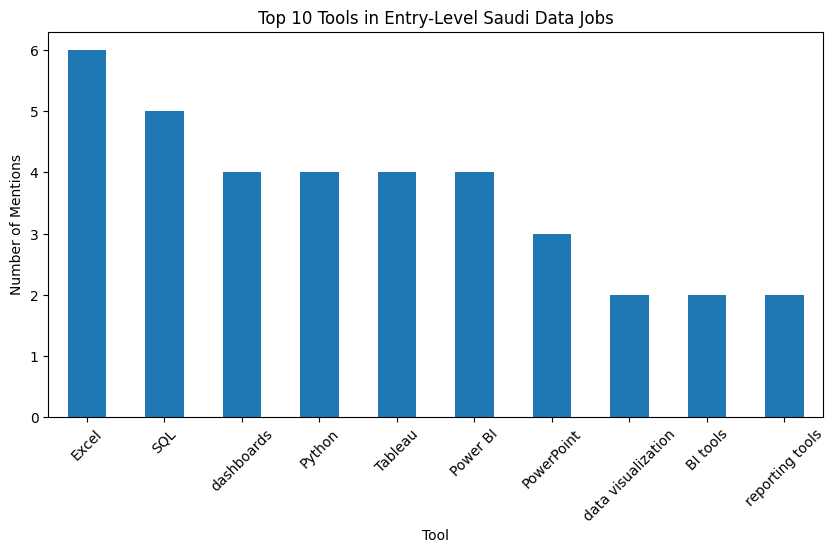

In [15]:
top_entry_tools = entry_tool_counts.head(10)

top_entry_tools.plot(kind='bar', figsize=(10, 5))

plt.title('Top 10 Tools in Entry-Level Saudi Data Jobs')
plt.xlabel('Tool')
plt.ylabel('Number of Mentions')
plt.xticks(rotation=45)
plt.show()

### Entry-Level Tools Insight

For entry-level Saudi data-related roles, the most repeated tools are expected to include SQL, Python, Excel, Power BI, and Tableau.

This suggests that students should prioritize SQL and Python first, then build dashboarding and reporting skills using Excel and Power BI.

## Entry-Level Skills Analysis

This section analyzes the most frequently mentioned skills in entry-level data-related job postings.

In [16]:
entry_skills_series = entry_level_jobs['skills'].str.split(',')
entry_skills_exploded = entry_skills_series.explode()
entry_skills_cleaned = entry_skills_exploded.str.strip()
entry_skill_counts = entry_skills_cleaned.value_counts()

entry_skill_counts.head(10)

,count
skills,
dashboarding,5
reporting,5
data analysis,5
data accuracy,4
trend analysis,4
data validation,4
problem solving,3
KPI tracking,3
insights generation,3


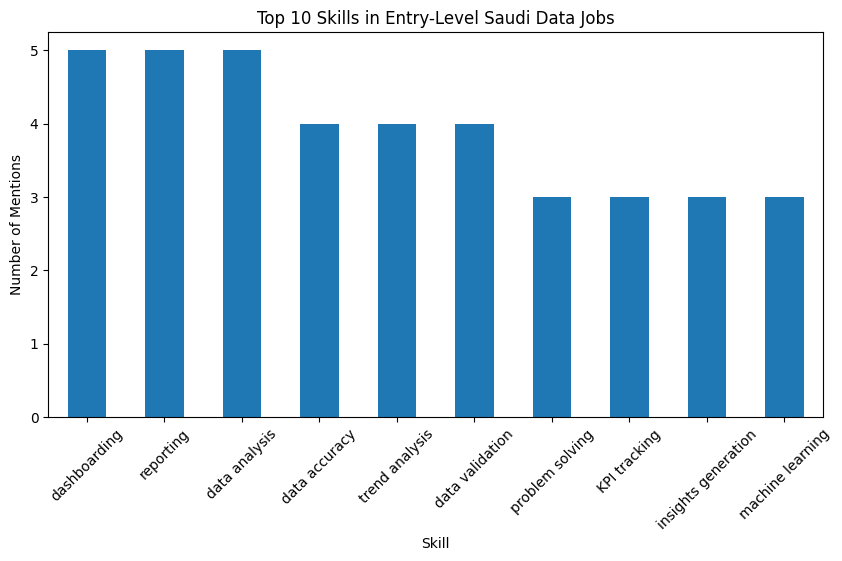

In [17]:
top_entry_skills = entry_skill_counts.head(10)

top_entry_skills.plot(kind='bar', figsize=(10, 5))

plt.title('Top 10 Skills in Entry-Level Saudi Data Jobs')
plt.xlabel('Skill')
plt.ylabel('Number of Mentions')
plt.xticks(rotation=45)
plt.show()

### Entry-Level Skills Insight

Entry-level data-related roles require a mix of technical, analytical, and business skills.

Important repeated skills include data analysis, reporting, dashboarding, data validation, problem solving, and insight generation.

## Role Category and Experience Level Comparison

This section compares role categories with experience levels to understand which role types appear most often for entry-level opportunities.

In [18]:
role_experience_counts = df.groupby(['role_category', 'experience_category'])['job_title'].count().reset_index()

role_experience_counts

,role_category,experience_category,job_title
0,AI,Entry Level,1
1,AI,Internship,2
2,AI,Mid-Level,1
3,BI,Entry Level,1
4,BI,Mid-Level,2
5,Data Analysis,Entry Level,4
6,Data Analysis,Mid-Level,5
7,Data Science,Entry Level,2
8,Governance,Entry Level,1
9,Governance,Mid-Level,1


In [19]:
role_experience_counts = role_experience_counts.sort_values(by='job_title', ascending=False)

role_experience_counts

,role_category,experience_category,job_title
6,Data Analysis,Mid-Level,5
5,Data Analysis,Entry Level,4
10,Other,Entry Level,3
1,AI,Internship,2
7,Data Science,Entry Level,2
11,Other,Mid-Level,2
4,BI,Mid-Level,2
0,AI,Entry Level,1
3,BI,Entry Level,1
2,AI,Mid-Level,1


### Role and Experience Insight

Using groupby helps compare job roles by experience level.

This analysis helps identify which types of data-related roles are more accessible for entry-level candidates.

## Day 6 Summary

In this notebook, I analyzed the cleaned Saudi data jobs dataset by role category and experience level.

Main tasks completed:
- Analyzed job postings by role category.
- Analyzed job postings by experience level.
- Filtered entry-level job postings.
- Identified the most repeated tools for entry-level roles.
- Identified the most repeated skills for entry-level roles.
- Compared role categories with experience levels using groupby.

Main takeaway:
Entry-level data-related roles in Saudi Arabia commonly require SQL, Python, Excel, Power BI, data analysis, reporting, dashboarding, and problem-solving skills.